# L2 Cache Behavior

In [1]:
from analyzer_functions import *

## Non-persistent L2 cache

In [2]:
#l1_path = 'data/l2/nonpersist/ada-l2NP-l1-100k.csv'
l1_path = 'data/l2/1106/ada-l11106-100k.csv'
#l2_path = 'data/l2/nonpersist/ada-l2NP-l2-100k.csv'
l2_path = 'data/l2/1106/ada-l21106-100k.csv'
spin_path = 'data/ada-spin-100k.csv'

l1_ivls = read_ivls(l1_path, single=True)
l2_ivls = read_ivls(l2_path, single=True)
spin_ivls = read_ivls(spin_path, single=True)

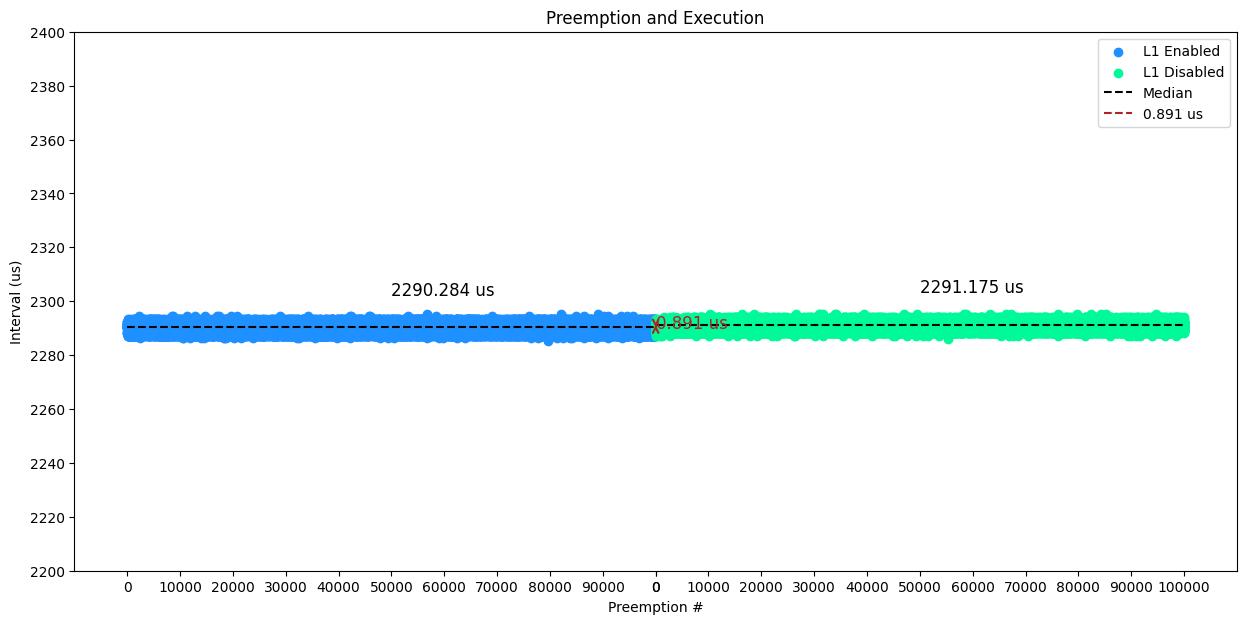

In [3]:
N = 100000
plot_side_by_side(noSharedData=l1_ivls, sharedData=l2_ivls, NUM_SAMPLES=N, lowerBound=2200, upperBound=2400,
 				  firstLabel='L1 Enabled', secondLabel='L1 Disabled', medianLines=True)

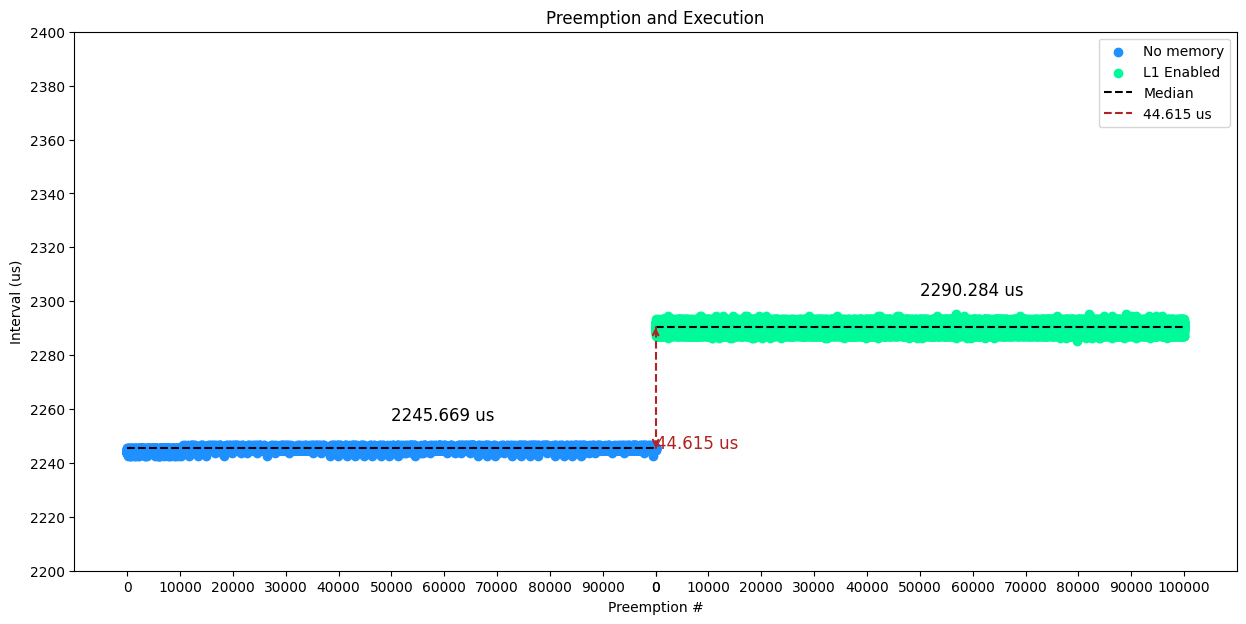

In [4]:
plot_side_by_side(noSharedData=spin_ivls, sharedData=l1_ivls, NUM_SAMPLES=N, lowerBound=2200, upperBound=2400,
 				  firstLabel='No memory', secondLabel='L1 Enabled', medianLines=True)

In [5]:
spin_oh = get_overhead(spin_ivls, 2131)
l1_oh = get_overhead(l1_ivls, 2131)

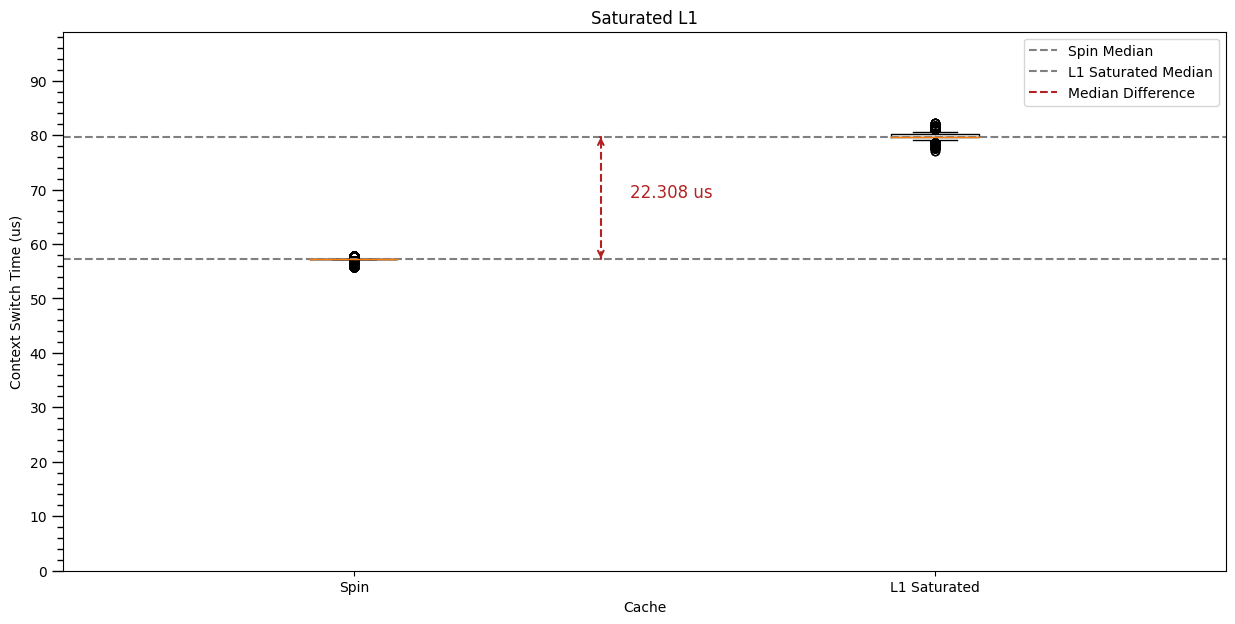

In [6]:
box_plotter(spin_oh, "Spin", l1_oh, "L1 Saturated", "Saturated L1", "Context Switch Time (us)", "Cache", ymin=0, ymax=100)

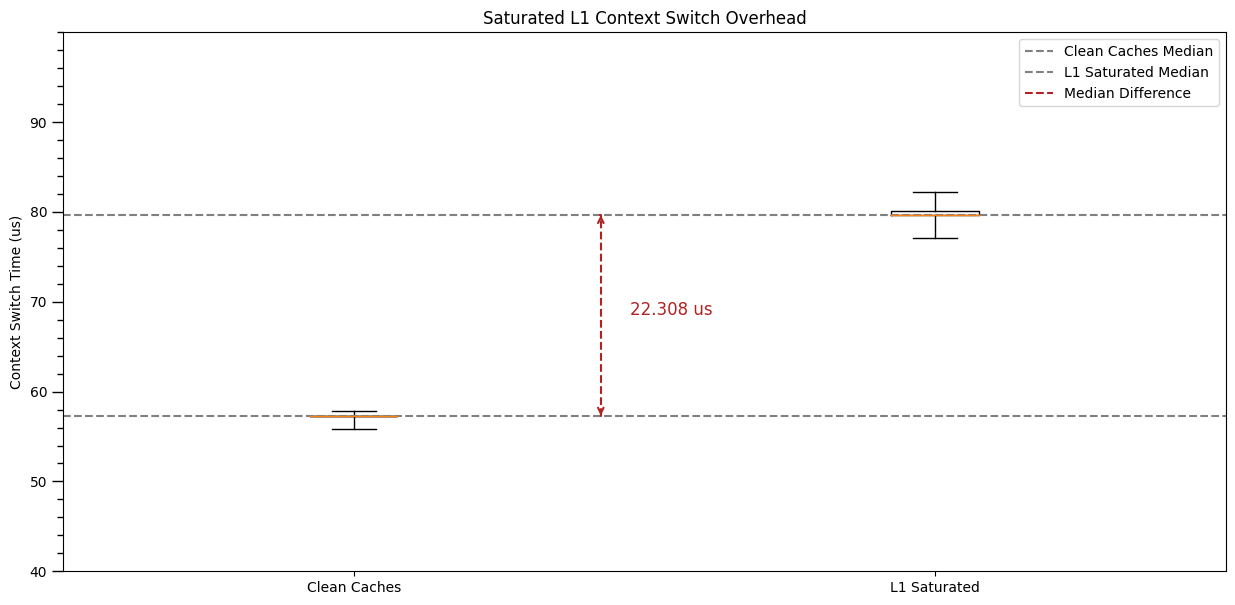

In [7]:
box_plotter(spin_oh, "Clean Caches", l1_oh, "L1 Saturated", "Saturated L1 Context Switch Overhead", "Context Switch Time (us)", "", ymin=40, ymax=100, fullRange=True)

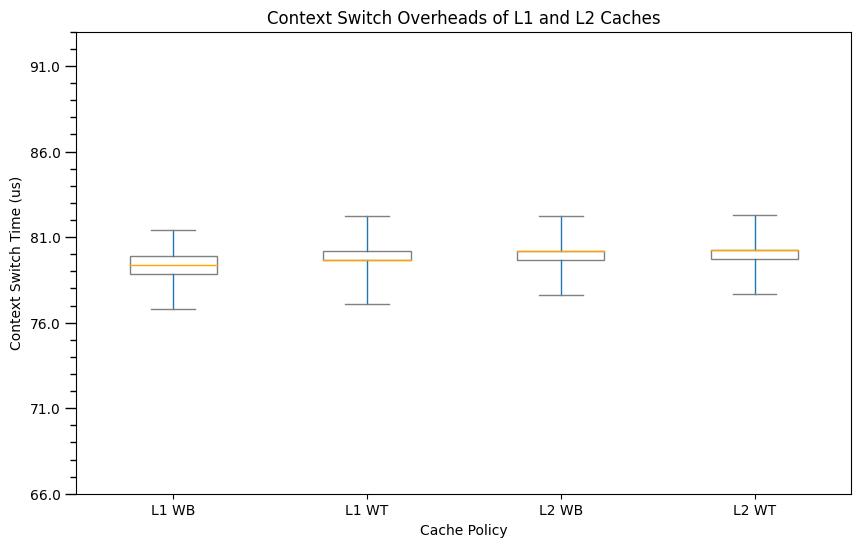

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create a dataframe of NumPy arrays
l1_wb_ivls = read_ivls('data/l2/cache-policies/ada-l1wb-100k.csv', single=True)
l1_wt_ivls = read_ivls('data/l2/cache-policies/ada-l1wt-100k.csv', single=True)
l2_wb_ivls = read_ivls('data/l2/cache-policies/ada-l2wb-100k.csv', single=True)
l2_wt_ivls = read_ivls('data/l2/cache-policies/ada-l2wt-100k.csv', single=True)
TIMESLICE_LENGTH = 2131
l1_wb = get_overhead(l1_wb_ivls, TIMESLICE_LENGTH)
l1_wt = get_overhead(l1_wt_ivls, TIMESLICE_LENGTH)
l2_wb = get_overhead(l2_wb_ivls, TIMESLICE_LENGTH)
l2_wt = get_overhead(l2_wt_ivls, TIMESLICE_LENGTH)
data = {
	'L1 WB': l1_wb,
	'L1 WT': l1_wt,
	'L2 WB': l2_wb,
	'L2 WT': l2_wt
}

# Convert the list of NumPy arrays to a DataFrame
df = pd.DataFrame(data)

# Create a boxplot
plt.figure(figsize=(10, 6))
df.boxplot(grid=False, 
           patch_artist=True,
           boxprops=dict(facecolor='none', color='gray'),
           flierprops=dict(markerfacecolor='red', marker='o', markersize=5),
           medianprops=dict(color='orange', linewidth=1),
		   capprops=dict(color='gray', linewidth=1),
		   whis=[0,100])

# Customize the plot
plt.title('Context Switch Overheads of L1 and L2 Caches')
plt.xlabel('Cache Policy')
plt.ylabel('Context Switch Time (us)')

# y ticks
ymin = np.floor(df.min().min()) - 10
ymax = np.ceil(df.max().max()) + 10
plt.ylim(ymin, ymax)
plt.yticks(np.arange(ymin, ymax, 1))
LABEL_STEP = 5
plt.gca().set_yticks(np.arange(ymin, ymax, LABEL_STEP).tolist())
plt.gca().set_yticklabels(np.arange(ymin, ymax, LABEL_STEP).tolist())

# Show minor ticks (for tick marks every 1 unit)
plt.gca().tick_params(axis='y', which='both', length=8, width=1)

# Show minor ticks and adjust their appearance
plt.gca().tick_params(axis='y', which='minor', length=4, width=1)

# Add minor ticks at every unit
plt.gca().minorticks_on()

# Disable minor ticks on the x-axis
plt.gca().tick_params(axis='x', which='minor', length=0)

# Show the plot
plt.show()